**Fake News Detection**

In [3]:
import pandas as pd
import numpy as np

https://www.kaggle.com/datasets/clmentbisaillon/fake-and-real-news-dataset

**Dataset**

In [5]:
fake_df = pd.read_csv('/content/drive/MyDrive/Fake News Dectection/Fake.csv.zip')
true_df = pd.read_csv('/content/drive/MyDrive/Fake News Dectection/True.csv.zip')

In [6]:
fake_df.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [7]:
true_df.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


**EDA**

In [9]:
#Add labels

fake_df['label'] = 1
true_df['label'] = 0

In [10]:
#Inspect the data
fake_df.head()

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",1
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",1
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",1
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",1
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",1


In [11]:
true_df.head()

,title,text,subject,date,label
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",0
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",0
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",0
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",0
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",0


In [12]:
fake_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23481 entries, 0 to 23480
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    23481 non-null  object
 1   text     23481 non-null  object
 2   subject  23481 non-null  object
 3   date     23481 non-null  object
 4   label    23481 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 917.4+ KB


In [13]:
true_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21417 entries, 0 to 21416
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    21417 non-null  object
 1   text     21417 non-null  object
 2   subject  21417 non-null  object
 3   date     21417 non-null  object
 4   label    21417 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 836.7+ KB


In [14]:
fake_df.isna().sum()

,0
title,0
text,0
subject,0
date,0
label,0


In [15]:
true_df.isna().sum()

,0
title,0
text,0
subject,0
date,0
label,0


In [16]:
#Train Test Split

from sklearn.model_selection import train_test_split

df = pd.concat([fake_df, true_df], ignore_index=True)

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df['label'],
    random_state=42)

In [17]:
print(train_df.shape)
print(test_df.shape)

(35918, 5)
(8980, 5)


In [19]:
#Verify class proportions
print(train_df['label'].value_counts(normalize=True))
print(test_df['label'].value_counts(normalize=True))

label
1    0.522997
0    0.477003
Name: proportion, dtype: float64
label
1    0.52294
0    0.47706
Name: proportion, dtype: float64


In [20]:
#Class Balance
train_df['label'].value_counts()

,count
label,
1,18785
0,17133


The subject variables exhibited near-perfect separation between classes, indicating target leakage. To ensure the model learns linguistic characteristics of misinformation rather than dataset-specific metadata, the subject feature was excluded from model training.

In [23]:
#Subject distribution
print(train_df["subject"].value_counts(),"\n\n")

print(pd.crosstab(
    train_df["subject"],
    train_df["label"]
))

subject
politicsNews       9056
worldnews          8077
News               7301
politics           5402
left-news          3569
Government News    1261
Middle-east         632
US_News             620
Name: count, dtype: int64 


label               0     1
subject                    
Government News     0  1261
Middle-east         0   632
News                0  7301
US_News             0   620
left-news           0  3569
politics            0  5402
politicsNews     9056     0
worldnews        8077     0


In [26]:
#Article Length

train_df["title_length"] = (
    train_df["title"]
    .str.split()
    .str.len()
)

train_df["text_length"] = (
    train_df["text"]
    .str.split()
    .str.len()
)

train_df.groupby("label")[
    ["title_length", "text_length"]
].describe()

title_length                                                    \
             count       mean       std  min   25%   50%   75%   max   
label                                                                  
0          17133.0   9.955408  1.696055  4.0   9.0  10.0  11.0  20.0   
1          18785.0  14.746074  4.348620  1.0  12.0  14.0  17.0  42.0   

      text_length                                                            
            count        mean         std  min    25%    50%    75%     max  
label                                                                        
0         17133.0  385.468511  275.810597  0.0  148.0  359.0  522.0  5172.0  
1         18785.0  423.008943  407.919150  0.0  240.0  364.0  506.0  8135.0

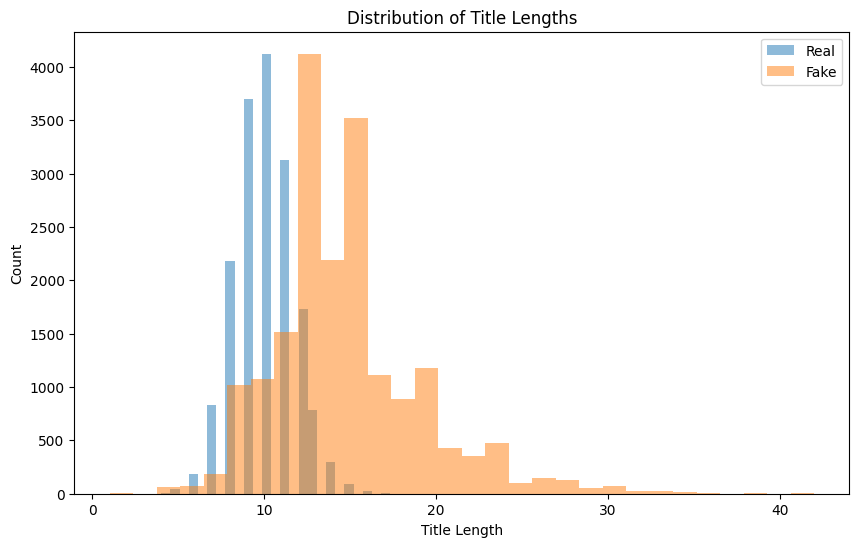

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.hist(
    train_df[train_df["label"] == 0]["title_length"],
    bins=30,
    alpha=0.5,
    label="Real"
)

plt.hist(
    train_df[train_df["label"] == 1]["title_length"],
    bins=30,
    alpha=0.5,
    label="Fake"
)

plt.xlabel("Title Length")
plt.ylabel("Count")
plt.title("Distribution of Title Lengths")
plt.legend()
plt.show()

**Feature Engineering**

**TF-IDF**

**Logistic Regression**

**XG Boost**

**CNN**

**Ensemble**

**Explainability**

**Knowlegde Graph**

**Conclusion**